In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
np.random.seed(42)
X=np.linspace(-3,3,100).reshape(-1,1)
y=np.sin(X).ravel()+np.random.normal(scale=0.1,size=X.shape[0])


In [3]:
def locally_weighted_regression(x_query ,X_train,y_train,tau):
    W=np.exp(-((X_train - x_query)**2 )/ (2*tau **2))
    X_bias=np.c_[np.ones_like(X_train),X_train]
    theta=np.linalg.pinv(X_bias.T @ np.diag(W.ravel()) @ X_bias) @ X_bias.T @np.diag(W.ravel()) @ y_train
    return np.array([1,x_query]) @theta

In [4]:
X_test=np.linspace(-3,3,100)
y_pred=np.array([locally_weighted_regression(x,X,y,tau=0.5) for x in X_test])

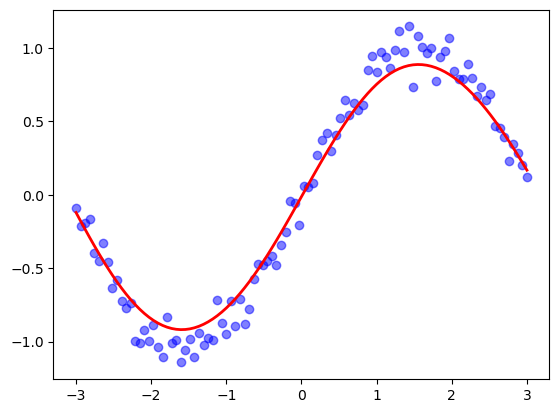

In [6]:
plt.scatter(X,y,color="blue",alpha=0.5,label="training data")
plt.plot(X_test,y_pred,color="red",linewidth=2,label="LWR Fit(tau=0.5)")